In [1]:
# Goal: have a table for all hotspots 
# comparing the population on 1km vs 0.25 degrees
# number of people on 1km vs 0.25, vs UN estimates, area, number of events in 2003&2012, max percentage affected


In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../exposure_to_hazards/')

from config import DATA_DIR
path_population_files = DATA_DIR / "population"


In [2]:
from climada.entity import Exposures

In [3]:
import geopandas as gpd
from shapely.geometry import Point

gdf_adm1 = gpd.read_file(path_population_files / "geoBoundariesCGAZ_ADM1/geoBoundariesCGAZ_ADM1.shp")
gdf_adm1 = gdf_adm1.to_crs("EPSG:4326")
gdf_adm1 =  gdf_adm1[gdf_adm1['shapeType']=='ADM1']
gdf_adm1_subset = gdf_adm1[gdf_adm1.shapeName.isin(['Wakayama Prefecture', 'ALTO PARAGUAY','Kwango','Jiangsu Province','Uttar Pradesh','Darkhan-Uul'])]

In [4]:
import geopandas as gpd

# Initialize an empty dictionary to store results for each year
results = {}

# Define bounding boxes for each region (with a 1-degree buffer)
bounding_boxes = {
    'Wakayama Prefecture': (134.0, 138.0, 32.0, 35.0),
    'Alto Paraguay': (-61.0, -55.0, -22.0, -18.0),
    'Kwango': (15.0, 20.0, -8.0, -4.0),
    'Jiangsu Province': (115.0, 123.0, 30.0, 36.0),
    'Uttar Pradesh': (76.0, 85.0, 24.0, 31.0),
    'Darkhan-Uul': (103.0, 107.0, 47.0, 51.0)
}

# Perform the filtering and spatial matching for the first year (e.g., 2012)
year = 2012
pop = Exposures.from_raster(f"/Users/szelie/OneDrive - ETH Zurich/data/health_multi_risk_data/population/worldpop/ppp_{year}_1km_Aggregated.tif")

# Subset the gdf based on points within the bounding boxes of all regions
gdf_subset = pop.gdf[
    (
        (pop.gdf['longitude'] >= bounding_boxes['Wakayama Prefecture'][0]) & (pop.gdf['longitude'] <= bounding_boxes['Wakayama Prefecture'][1]) &
        (pop.gdf['latitude'] >= bounding_boxes['Wakayama Prefecture'][2]) & (pop.gdf['latitude'] <= bounding_boxes['Wakayama Prefecture'][3])
    )
    |
    (
        (pop.gdf['longitude'] >= bounding_boxes['Alto Paraguay'][0]) & (pop.gdf['longitude'] <= bounding_boxes['Alto Paraguay'][1]) &
        (pop.gdf['latitude'] >= bounding_boxes['Alto Paraguay'][2]) & (pop.gdf['latitude'] <= bounding_boxes['Alto Paraguay'][3])
    )
    |
    (
        (pop.gdf['longitude'] >= bounding_boxes['Kwango'][0]) & (pop.gdf['longitude'] <= bounding_boxes['Kwango'][1]) &
        (pop.gdf['latitude'] >= bounding_boxes['Kwango'][2]) & (pop.gdf['latitude'] <= bounding_boxes['Kwango'][3])
    )
    |
    (
        (pop.gdf['longitude'] >= bounding_boxes['Jiangsu Province'][0]) & (pop.gdf['longitude'] <= bounding_boxes['Jiangsu Province'][1]) &
        (pop.gdf['latitude'] >= bounding_boxes['Jiangsu Province'][2]) & (pop.gdf['latitude'] <= bounding_boxes['Jiangsu Province'][3])
    )
    |
    (
        (pop.gdf['longitude'] >= bounding_boxes['Uttar Pradesh'][0]) & (pop.gdf['longitude'] <= bounding_boxes['Uttar Pradesh'][1]) &
        (pop.gdf['latitude'] >= bounding_boxes['Uttar Pradesh'][2]) & (pop.gdf['latitude'] <= bounding_boxes['Uttar Pradesh'][3])
    )
    |
    (
        (pop.gdf['longitude'] >= bounding_boxes['Darkhan-Uul'][0]) & (pop.gdf['longitude'] <= bounding_boxes['Darkhan-Uul'][1]) &
        (pop.gdf['latitude'] >= bounding_boxes['Darkhan-Uul'][2]) & (pop.gdf['latitude'] <= bounding_boxes['Darkhan-Uul'][3])
    )
]

# Convert the subset into a GeoDataFrame with geometry
gdf_subset['geometry'] = gpd.points_from_xy(gdf_subset.longitude, gdf_subset.latitude)
gdf_subset = gpd.GeoDataFrame(gdf_subset, geometry='geometry')

# Ensure CRS matches before spatial join
if gdf_subset.crs != gdf_adm1_subset.crs:
    gdf_subset.crs = gdf_adm1_subset.crs

# Perform the spatial join to get points within the polygons
points_within_polygons = gpd.sjoin(gdf_subset, gdf_adm1_subset, how="left", predicate='within')

# Create an Exposures object for the filtered data and save the first year
exposure_test = Exposures(points_within_polygons.dropna())
output_file = f'/Users/szelie/OneDrive - ETH Zurich/data/health_multi_risk_data/test_data/exposure_test_{year}.hdf5'
exposure_test.write_hdf5(output_file)
results[year] = exposure_test

# Reuse the filtered points for subsequent years
filtered_points = points_within_polygons.dropna()

# Now 'results' contains the exposures for each year that can be accessed directly for further analysis


<Axes: >

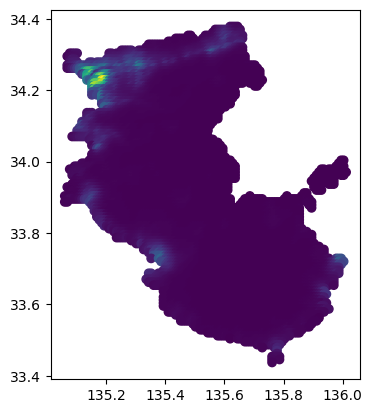

In [10]:
exposure_test.gdf.plot('value')

In [5]:
admin_by_point_test = exposure_test.gdf.rename(columns={'shapeGroup':'ISO3', 'shapeName':'ADM1_NAME', 'shapeID': 'ADM1_ID'})
admin_by_point_test = admin_by_point_test.drop_duplicates(subset=['latitude', 'longitude'], keep='first')
#admin_by_point_test.to_csv(path_population_files / f"{age}_worldpop_admin_by_point.csv")

NameError: name 'exposure_test' is not defined

In [5]:
import pandas as pd
adm1_pop_by_year_test= []
for year in [2003,2012]:
    admin_by_point_test = Exposures.from_hdf5(f'/Users/szelie/OneDrive - ETH Zurich/data/health_multi_risk_data/test_data/exposure_test_{year}.hdf5').gdf
    print(admin_by_point_test.value.sum()) 
    admin_by_point_test = admin_by_point_test.rename(columns={'shapeGroup':'ISO3', 'shapeName':'ADM1_NAME', 'shapeID': 'ADM1_ID'})
    admin_by_point_test = admin_by_point_test.drop_duplicates(subset=['latitude', 'longitude'], keep='first')
    year_data = admin_by_point_test[['ADM1_NAME','ADM1_ID','value']].groupby(['ADM1_NAME','ADM1_ID']).sum().reset_index()
    year_data['year'] = year
    adm1_pop_by_year_test.append(year_data)
adm1_pop_by_year_test = pd.concat(adm1_pop_by_year_test)

247570780.0
282804540.0


In [8]:
admin_by_point_test.ADM1_NAME.unique()

array(['Wakayama Prefecture', 'ALTO PARAGUAY'], dtype=object)

In [6]:
from pathlib import Path

import itertools
from climada.engine import Impact
combinations = []

hazards = ['HW_test','EP_test','RF_test', 'TC_test', 'DR_test','FI_test']

for r in range(1, len(hazards) + 1):
    combinations.extend(list(itertools.combinations(hazards, r)))

combinations = ["-".join(combi) for combi in combinations]

IMPACT_DIR = DATA_DIR / "impacts"

imp_combined_test = {}
for age in ['all']:
    imp_combined_test[age] = {}
    for combi in combinations:
        imp_combined_test[age][combi] = Impact.from_csv(IMPACT_DIR / f"csv/{combi}_{age}_2003_2022.csv")
        imp_combined_test[age][combi].imp_mat = Impact.read_sparse_csr(IMPACT_DIR / f"npz/{combi}_{age}_2003_2022.npz")
        imp_combined_test[age][combi]



2024-10-04 19:41:24,150 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:41:24,720 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:41:25,242 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


...

2024-10-04 19:41:33,039 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:41:33,519 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/szelie/OneDrive - ETH Zurich/data/health_multi_risk_data/impacts/csv/DR_test-FI_test_all_2003_2022.csv'

In [7]:
import pandas as pd
admin_by_point_test['numeric'] = pd.factorize(admin_by_point_test["ADM1_ID"])[0]


In [8]:
import datetime
rel_country_imp_test = {}
mean_rel_country_imp = {}
age = 'all'
for combi in imp_combined_test['all']:

    at_reg = imp_combined_test[age][combi].impact_at_reg(agg_regions=admin_by_point_test['numeric'])
    
    # Prepare the data for plotting
    at_reg['month'] = [datetime.datetime.fromordinal(int(date)).month for date in imp_combined_test[age][combi].date]
    at_reg['year'] = [datetime.datetime.fromordinal(int(date)).year for date in imp_combined_test[age][combi].date]
    
    # Melt and merge data
    at_reg_melted = at_reg.melt(id_vars=['month', 'year'], var_name='numeric', value_name='impact')
    at_reg_melted = at_reg_melted.merge(admin_by_point_test[["ADM1_ID", "ADM1_NAME", "ISO3", "numeric"]].drop_duplicates())
    at_reg_melted = at_reg_melted.merge(adm1_pop_by_year_test, on=['year', "ADM1_ID", "ADM1_NAME"], how='inner')

    
    at_reg_melted['relative_impact'] = at_reg_melted['impact'] / at_reg_melted['value']

    rel_country_imp_test[combi] = at_reg_melted
    

In [16]:
rel_country_imp_test['HW_test']

,month,year,numeric,impact,ADM1_ID,ADM1_NAME,ISO3,value,relative_impact
0,1,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
1,2,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
2,3,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
3,4,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
4,5,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
5,6,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
6,7,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000
7,8,2003,0,987557.313307,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.982228
8,9,2003,0,363251.667588,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.361291
9,10,2003,0,0.000000,47310658B18585040133157,Wakayama Prefecture,JPN,1.005426e+06,0.000000


In [9]:
from pathlib import Path

import itertools
from climada.engine import Impact
combinations = []

hazards = ['RF','EP','DR','HW','FI','TC']

for r in range(1, len(hazards) + 1):
    combinations.extend(list(itertools.combinations(hazards, r)))

combinations = ["-".join(combi) for combi in combinations]

IMPACT_DIR = DATA_DIR / "impacts"

imp_combined = {}
for age in ['all']:
    imp_combined[age] = {}
    for combi in combinations:
        imp_combined[age][combi] = Impact.from_csv(IMPACT_DIR / f"csv/{combi}_{age}_2003_2022.csv")
        imp_combined[age][combi].imp_mat = Impact.read_sparse_csr(IMPACT_DIR / f"npz/{combi}_{age}_2003_2022.npz")
        imp_combined[age][combi]



2024-10-04 19:41:45,117 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:41:45,770 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:41:46,455 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


...

/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:42:21,751 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


2024-10-04 19:42:22,317 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/Users/szelie/python_projects/climada_python/climada/engine/impact.py:1081: DtypeWarning: Columns (1,5,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  imp_df = pd.read_csv(file_name)


In [10]:
import pandas as pd
import datetime
adm1_pop_by_year = pd.read_csv(DATA_DIR / "population/all_worldpop_by_admin1_by_year_2000_2022.csv")

agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")
agg_regions['numeric'] = pd.factorize(agg_regions["ADM1_ID"])[0]


import matplotlib.pyplot as plt
from cartopy import crs
import geopandas as gpd

rel_country_imp = {}
mean_rel_country_imp = {}
age = 'all'
for combi in imp_combined['all']:

    at_reg = imp_combined[age][combi].impact_at_reg(agg_regions=agg_regions['numeric'])
    
    # Prepare the data for plotting
    at_reg['month'] = [datetime.datetime.fromordinal(int(date)).month for date in imp_combined[age][combi].date]
    at_reg['year'] = [datetime.datetime.fromordinal(int(date)).year for date in imp_combined[age][combi].date]
    
    # Melt and merge data
    at_reg_melted = at_reg.melt(id_vars=['month', 'year'], var_name='numeric', value_name='impact')
    at_reg_melted = at_reg_melted.merge(agg_regions[["ADM1_ID", "ADM1_NAME", "ISO3", "numeric"]].drop_duplicates())
    at_reg_melted = at_reg_melted.merge(adm1_pop_by_year, on=['year', "ADM1_ID", "ADM1_NAME", "ISO3"], how='inner')

    
    at_reg_melted['relative_impact'] = at_reg_melted['impact'] / at_reg_melted['value']

    rel_country_imp[combi] = at_reg_melted
    

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_28051/3374328586.py:5: DtypeWarning: Columns (7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  agg_regions = pd.read_csv(DATA_DIR / "population/all_worldpop_admin_by_point.csv")


In [26]:
adm1_list = list(bounding_boxes.keys()) + ["ALTO PARAGUAY"]

In [44]:
df1 = rel_country_imp['FI'][rel_country_imp['FI'].ADM1_NAME.isin(adm1_list)]
df1 =df1[df1.year.isin([2003,2012])]
df2 = rel_country_imp_test['FI_test'][rel_country_imp_test['FI_test'].relative_impact>0]


In [45]:
df2 = rel_country_imp_test['FI_test'][rel_country_imp_test['FI_test'].relative_impact>0]
#df2 =df2[df2.ADM1_NAME.isin(['ALTO PARAGUAY'])]

In [59]:
gdf_adm1

,shapeName,shapeID,shapeGroup,shapeType,geometry,area
0,Kandahar,12653393B40111500734429,AFG,ADM1,"POLYGON ((65.24153 32.28630, 65.72553 32.48037...",5.037819e-06
1,Zabul,12653393B56617740339660,AFG,ADM1,"POLYGON ((67.60666 31.44378, 67.60882 31.44909...",1.678300e-06
2,Uruzgan,12653393B46006342616872,AFG,ADM1,"POLYGON ((66.27519 32.42550, 65.72553 32.48037...",1.039419e-06
3,Daykundi,12653393B78791504725813,AFG,ADM1,"POLYGON ((66.76157 33.25547, 66.38975 33.30701...",1.749127e-06
4,Ghanzi,12653393B29313712249365,AFG,ADM1,"POLYGON ((68.06945 32.04564, 67.86439 32.14395...",2.211272e-06
...,...,...,...,...,...,...
3199,Niger,27671186B79778155682183,NGA,ADM1,"POLYGON ((3.68429 10.15667, 3.67667 10.18389, ...",5.862373e-06
3200,Kaduna,27671186B54051914323789,NGA,ADM1,"POLYGON ((7.72408 9.32925, 7.69297 9.34940, 7....",3.720720e-06
3201,Enugu,27671186B90910891533368,NGA,ADM1,"POLYGON ((6.86097 6.75343, 6.87828 6.76058, 6....",6.234814e-07
3202,Taraba,27671186B83252759475924,NGA,ADM1,"POLYGON ((11.19655 6.53719, 11.19630 6.53711, ...",4.775470e-06


In [63]:

# Check the current CRS
print(f"Original CRS: {gdf_adm1.crs}")

# Reproject to a CRS that uses meters (e.g., EPSG:3395 or EPSG:3857)
# This ensures accurate area calculations in square meters
gdf_adm1 = gdf_adm1.to_crs(epsg=3395)  # WGS 84 / World Mercator, or you can use 3857

# Calculate the area in square kilometers (area in meters / 10^6 for km²)
gdf_adm1['area'] = gdf_adm1['geometry'].area / 10**6  # Convert from square meters to square kilometers

# Extract the required columns (ADM1_NAME and area)
area_df = gdf_adm1[['ADM1_NAME', 'area']].copy()

# Now integrate the area_df into your analysis as in the previous steps
# (Continue from the previous code for merging area_df with the final dataframe)


Original CRS: EPSG:4326


In [64]:
area_df

,ADM1_NAME,area
0,Kandahar,72487.268269
1,Zabul,24474.556199
2,Uruzgan,15257.389189
3,Daykundi,25944.487600
4,Ghanzi,32631.243800
...,...,...
3199,Niger,73277.623892
3200,Kaduna,46572.872657
3201,Enugu,7725.467731
3202,Taraba,59372.960188


In [139]:
import pandas as pd

# List of hazards to compare
hazards = ['RF', 'EP', 'DR', 'HW', 'FI', 'TC']

# Create an empty list to store the results for each hazard
hazard_dfs = []

# Iterate over each hazard
for hazard in hazards:
    
    # Filter df1 and df2 for the given hazard and for the year 2012 only
    df1_hazard = rel_country_imp[hazard][rel_country_imp[hazard].ADM1_NAME.isin(adm1_list)]
    df1_hazard = df1_hazard[df1_hazard.year == 2012]
    
    df2_hazard = rel_country_imp_test[hazard + '_test'][rel_country_imp_test[hazard + '_test'].relative_impact > 0]
    df2_hazard = df2_hazard[df2_hazard.year == 2012]

    # Ensure that relative impact is greater than 1% before counting events (0.01 threshold)
    df1_hazard = df1_hazard[df1_hazard['relative_impact'] > 0.01]
    df2_hazard = df2_hazard[df2_hazard['relative_impact'] > 0.01]

    # Group by ADM1_NAME and calculate the maximum impact and number of events for df1
    df1_grouped = df1_hazard.groupby('ADM1_NAME').agg(
        max_impact_0_25_degrees=('relative_impact', 'max'),  # Max relative impact
        events_0_25_degrees=('ADM1_NAME', 'count')           # Count number of events where relative_impact > 0.01
    ).reset_index()
    
    # Group by ADM1_NAME and calculate the maximum impact and number of events for df2
    df2_grouped = df2_hazard.groupby('ADM1_NAME').agg(
        max_impact_1km=('relative_impact', 'max'),           # Max relative impact
        events_1km=('ADM1_NAME', 'count')                    # Count number of events where relative_impact > 0.01
    ).reset_index()
    
    # Merge the two dataframes on ADM1_NAME to compare df1 and df2
    merged_df = pd.merge(df1_grouped, df2_grouped, on='ADM1_NAME', how='outer', suffixes=('_0.25_degrees', '_1km'))
    
    # Rename columns for clarity and add hazard as prefix for each hazard
    merged_df = merged_df.rename(columns={
        'max_impact_0_25_degrees': f'{hazard}_max_impact_0.25_degrees',
        'max_impact_1km': f'{hazard}_max_impact_1km',
        'events_0_25_degrees': f'{hazard}_events_0.25_degrees',
        'events_1km': f'{hazard}_events_1km'
    })

    # Add the result to the list
    hazard_dfs.append(merged_df)

# Merge all hazard dataframes into one single dataframe on ADM1_NAME
final_comparison_df = hazard_dfs[0]
for hazard_df in hazard_dfs[1:]:
    final_comparison_df = pd.merge(final_comparison_df, hazard_df, on='ADM1_NAME', how='outer')

# Now, merge population data only for the year 2012

# First, merge the two population dataframes together to avoid duplicates
population_0_25 = rel_country_imp[hazards[0]][rel_country_imp[hazards[0]].year == 2012].groupby('ADM1_NAME')['value'].first().reset_index()
population_1km = rel_country_imp_test[hazards[0] + '_test'][rel_country_imp_test[hazards[0] + '_test'].year == 2012].groupby('ADM1_NAME')['value'].first().reset_index()

# Rename the population columns
population_0_25 = population_0_25.rename(columns={'value': 'population_0_25_degrees'})
population_1km = population_1km.rename(columns={'value': 'population_1km'})

# Merge both population datasets together before merging into final_comparison_df
merged_population = pd.merge(population_0_25, population_1km, on='ADM1_NAME', how='outer')

# Now merge the population data into the final comparison dataframe
final_comparison_df = pd.merge(final_comparison_df, merged_population, on='ADM1_NAME', how='outer')

# --- Add the area data ---
# Ensure area is added only once
if 'area' not in final_comparison_df.columns:
    final_comparison_df = pd.merge(final_comparison_df, area_df[['ADM1_NAME', 'area']], on='ADM1_NAME', how='outer')

# Handle missing values (e.g., fill NaN values with 0 for population and area if needed)
final_comparison_df.fillna(0, inplace=True)

# Rearrange the columns with population and area at the beginning
area_columns = ['population_0_25_degrees', 'population_1km', 'area']
comparison_columns = final_comparison_df.columns.difference(area_columns + ['ADM1_NAME']).tolist()
comparison_columns = area_columns + comparison_columns

# Reorder the final dataframe
final_comparison_df = final_comparison_df[['ADM1_NAME'] + area_columns + comparison_columns]

# Display the final comparison table
print(final_comparison_df)

# If you need to export to a file, use:
# final_comparison_df.to_csv('hazard_comparison.csv', index=False)


                ADM1_NAME  population_0_25_degrees  population_1km  \
0           ALTO PARAGUAY             3.353744e+04    1.519747e+04   
1        Jiangsu Province             7.452481e+07    7.635991e+07   
2           Uttar Pradesh             1.984581e+08    2.034512e+08   
3                  Kwango             1.924833e+06    1.944302e+06   
4     Wakayama Prefecture             9.477098e+05    9.408079e+05   
...                   ...                      ...             ...   
3197             Umm Slal             0.000000e+00    0.000000e+00   
3198            Al Daayen             0.000000e+00    0.000000e+00   
3199                Ajman             0.000000e+00    0.000000e+00   
3200               Yalova             0.000000e+00    0.000000e+00   
3201          Lakshadweep             0.000000e+00    0.000000e+00   

               area  population_0_25_degrees  population_1km           area  \
0      89711.042814             3.353744e+04    1.519747e+04   89711.042814   
1

In [140]:
final_comparison_df = final_comparison_df[final_comparison_df.ADM1_NAME.isin(adm1_list)]

In [141]:
import pandas as pd

# Official population values for 2012
official_population = pd.DataFrame({
    'ADM1_NAME': [
        'Wakayama Prefecture', 'ALTO PARAGUAY', 'Kwango', 'Jiangsu Province', 'Uttar Pradesh', 'Darkhan-Uul'
    ],
    'official_population_2012': [
        1002198, 16632, 1098000, 79400000, 199812341, 94000  # 2012 population values
    ]
})

# Merge the official population data into the final dataframe
final_comparison_df = pd.merge(final_comparison_df, official_population, on='ADM1_NAME', how='left')


In [136]:
final_comparison_df

,ADM1_NAME,population_0_25_degrees,population_1km,area,population_0_25_degrees,population_1km,area,DR_events_0.25_degrees,DR_events_1km,DR_max_impact_0.25_degrees,...,HW_max_impact_1km,RF_events_0.25_degrees,RF_events_1km,RF_max_impact_0.25_degrees,RF_max_impact_1km,TC_events_0.25_degrees,TC_events_1km,TC_max_impact_0.25_degrees,TC_max_impact_1km,official_population_2012
0,ALTO PARAGUAY,3.353744e+04,1.519747e+04,89711.042814,3.353744e+04,1.519747e+04,89711.042814,1.0,1.0,0.741226,...,1.000000,3.0,4.0,0.026694,0.051160,0.0,0.0,0.00000,0.000000,16632
1,Jiangsu Province,7.452481e+07,7.635991e+07,134145.265853,7.452481e+07,7.635991e+07,134145.265853,0.0,0.0,0.000000,...,1.000000,1.0,1.0,0.040411,0.030921,0.0,0.0,0.00000,0.000000,79400000
2,Uttar Pradesh,1.984581e+08,2.034512e+08,303007.876829,1.984581e+08,2.034512e+08,303007.876829,1.0,1.0,0.197099,...,0.988784,2.0,2.0,0.031377,0.030948,0.0,0.0,0.00000,0.000000,199812341
3,Kwango,1.924833e+06,1.944302e+06,90428.715671,1.924833e+06,1.944302e+06,90428.715671,0.0,0.0,0.000000,...,0.063538,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,1098000
4,Wakayama Prefecture,9.477098e+05,9.408079e+05,6792.719623,9.477098e+05,9.408079e+05,6792.719623,0.0,0.0,0.000000,...,0.949242,0.0,0.0,0.000000,0.000000,2.0,2.0,0.12907,0.208067,1002198
5,Darkhan-Uul,9.380755e+04,9.318904e+04,8925.258925,9.380755e+04,9.318904e+04,8925.258925,0.0,0.0,0.000000,...,0.995948,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,94000


In [107]:
final_comparison_df

,0,1,2,3,4,5
ADM1_NAME,ALTO PARAGUAY,Jiangsu Province,Uttar Pradesh,Kwango,Wakayama Prefecture,Darkhan-Uul
population_0_25_degrees,33537.444513,74524813.128906,198458124.851562,1924832.862793,947709.816406,93807.554184
population_1km,15197.474609,76359912.0,203451216.0,1944302.25,940807.875,93189.039062
area,89711.042814,134145.265853,303007.876829,90428.715671,6792.719623,8925.258925
DR_events_0.25_degrees,1.0,0.0,1.0,0.0,0.0,0.0
DR_max_impact_0.25_degrees,0.741226,0.0,0.197099,0.0,0.0,0.0
DR_max_impact_1km,0.9302,0.0,0.201879,0.0,0.0,0.0
EP_events_0.25_degrees,5.0,2.0,3.0,5.0,1.0,0.0
EP_events_1km,4.0,2.0,3.0,4.0,1.0,0.0
EP_max_impact_0.25_degrees,0.383158,0.29095,0.125222,0.057418,0.22006,0.0


In [142]:
final_comparison_df = final_comparison_df.transpose()


In [151]:
final_comparison_df

,0,1,2,3,4,5
ADM1_NAME,ALTO PARAGUAY,Jiangsu Province,Uttar Pradesh,Kwango,Wakayama Prefecture,Darkhan-Uul
population_0_25_degrees,33537.444513,74524813.128906,198458124.851562,1924832.862793,947709.816406,93807.554184
population_1km,15197.474609,76359912.0,203451216.0,1944302.25,940807.875,93189.039062
area,89711.042814,134145.265853,303007.876829,90428.715671,6792.719623,8925.258925
population_0_25_degrees,33537.444513,74524813.128906,198458124.851562,1924832.862793,947709.816406,93807.554184
population_1km,15197.474609,76359912.0,203451216.0,1944302.25,940807.875,93189.039062
area,89711.042814,134145.265853,303007.876829,90428.715671,6792.719623,8925.258925
DR_events_0.25_degrees,1.0,0.0,1.0,0.0,0.0,0.0
DR_events_1km,1.0,0.0,1.0,0.0,0.0,0.0
DR_max_impact_0.25_degrees,0.741226,0.0,0.197099,0.0,0.0,0.0


In [152]:
import pandas as pd

# Assuming the dataframe is loaded or already defined as `final_comparison_df`

# Step 1: Replace underscores with spaces and replace 'impact' with 'exposure'
final_comparison_df.index = final_comparison_df.index.str.replace('_', ' ').str.replace('impact', 'exposure')

# Step 2: Format population in millions
# Assuming the population rows have 'population' in the index
final_comparison_df.loc[final_comparison_df.index.str.contains('population')] = final_comparison_df.loc[
    final_comparison_df.index.str.contains('population')
].apply(lambda x: x / 10**6).applymap(lambda x: f'{x:.2f}M')

# Step 3: Format exposure values as percentages
# Assuming exposure rows have 'exposure' in the index
final_comparison_df.loc[final_comparison_df.index.str.contains('exposure')] = final_comparison_df.loc[
    final_comparison_df.index.str.contains('exposure')
].applymap(lambda x: f'{x * 100:.2f}%')

# Display the final result
print(final_comparison_df)

# If you need to export to a file:
# final_comparison_df.to_csv('formatted_comparison.csv', index=True)


                                          0                 1              2  \
ADM1 NAME                     ALTO PARAGUAY  Jiangsu Province  Uttar Pradesh   
population 0 25 degrees               0.03M            74.52M        198.46M   
population 1km                        0.02M            76.36M        203.45M   
area                           89711.042814     134145.265853  303007.876829   
population 0 25 degrees               0.03M            74.52M        198.46M   
population 1km                        0.02M            76.36M        203.45M   
area                           89711.042814     134145.265853  303007.876829   
DR events 0.25 degrees                  1.0               0.0            1.0   
DR events 1km                           1.0               0.0            1.0   
DR max exposure 0.25 degrees         74.12%             0.00%         19.71%   
DR max exposure 1km                  93.02%             0.00%         20.19%   
EP events 0.25 degrees                  

/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_28051/3505848305.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ].apply(lambda x: x / 10**6).applymap(lambda x: f'{x:.2f}M')
/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_28051/3505848305.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ].applymap(lambda x: f'{x * 100:.2f}%')


In [153]:
final_comparison_df

,0,1,2,3,4,5
ADM1 NAME,ALTO PARAGUAY,Jiangsu Province,Uttar Pradesh,Kwango,Wakayama Prefecture,Darkhan-Uul
population 0 25 degrees,0.03M,74.52M,198.46M,1.92M,0.95M,0.09M
population 1km,0.02M,76.36M,203.45M,1.94M,0.94M,0.09M
area,89711.042814,134145.265853,303007.876829,90428.715671,6792.719623,8925.258925
population 0 25 degrees,0.03M,74.52M,198.46M,1.92M,0.95M,0.09M
population 1km,0.02M,76.36M,203.45M,1.94M,0.94M,0.09M
area,89711.042814,134145.265853,303007.876829,90428.715671,6792.719623,8925.258925
DR events 0.25 degrees,1.0,0.0,1.0,0.0,0.0,0.0
DR events 1km,1.0,0.0,1.0,0.0,0.0,0.0
DR max exposure 0.25 degrees,74.12%,0.00%,19.71%,0.00%,0.00%,0.00%
